#  Kyasanur Forest Disease Prediction Using CNN-Lstm, GRU, Transformer Networks

**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import pickle
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, GRU, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, Add)

Load The **Dataset**

In [2]:
df = pd.read_csv("/content/KFD_399 (1).csv")
print(df.head())


df.info()


df.isnull().sum()


  Season GPS_loc Occupation sudden chills headache severe myalgia fever  \
0      P       P          P             Y        Y              Y     Y   
1      P       P          N             Y        N              N     N   
2      P       P          N             N        Y              N     N   
3      P       P          N             N        N              Y     N   
4      P       P          N             N        N              N     Y   

  joint pain neck pain cough  ... blood in stool Blood in cough  \
0          Y         Y     Y  ...              Y              Y   
1          N         N     N  ...              N              N   
2          N         N     N  ...              N              N   
3          N         N     N  ...              N              N   
4          N         N     N  ...              N              N   

  blood in vomit red eye neck stiffness mental disturbances giddiness  \
0              Y       Y              Y                   Y         Y   


,0
Season,0
GPS_loc,0
Occupation,0
sudden chills,0
headache,0
severe myalgia,0
fever,0
joint pain,0
neck pain,0
cough,0


**Input Features**

In [3]:
binary_columns = [
    'Season', 'GPS_loc', 'Occupation',
    'sudden chills', 'headache', 'severe myalgia', 'fever',
    'joint pain', 'neck pain', 'cough', 'diarhoea', 'vomiting',
    'photophobia', 'bloody nose', 'bloody gum', 'blood in stool',
    'Blood in cough', 'blood in vomit', 'red eye', 'neck stiffness',
    'mental disturbances', 'giddiness', 'unconsciousness', 'low bp']

**Pre Processing**

In [4]:
for col in binary_columns:
    df[col] = df[col].map({'Y': 1, 'N': 0, 'P': 1}).astype(int)


df['KFD'] = df['KFD'].map({
    'C': 'Confirmed',
    'N': 'Negative',
    'PR': 'Probable',
    'S': 'Suspected'
})
df = df[df['KFD'].notna()]

Encoding(Label Encoder)**bold text**

In [5]:
custom_class_order = ['Confirmed', 'Negative', 'Probable', 'Suspected']
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(custom_class_order)
df['KFD_encoded'] = df['KFD'].map({label: idx for idx, label in enumerate(custom_class_order)})

**Saving Encoder File(PKL file)**

In [6]:
with open("/content/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder.classes_, f)

**HISTOGRAM(Visualization)**

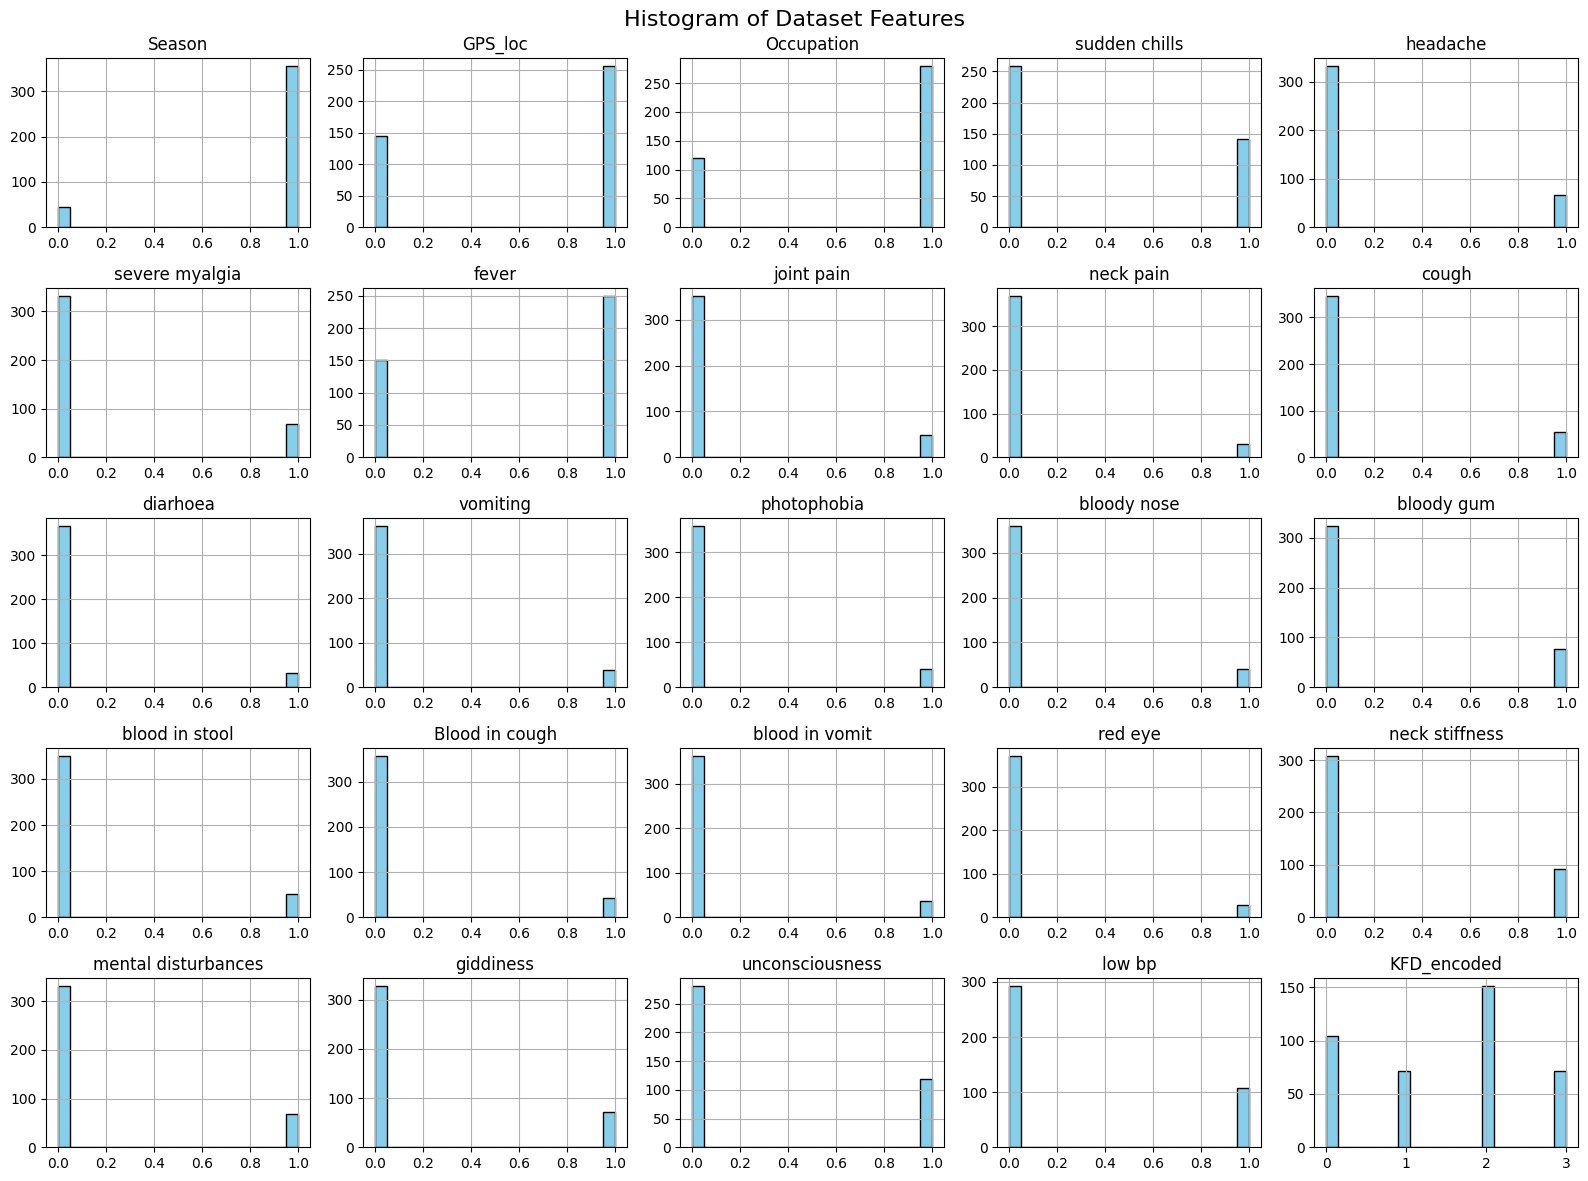

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
df.hist(figsize=(16, 12), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Histogram of Dataset Features", fontsize=16)
plt.tight_layout()
plt.show()


**BOX PLOT(Visualization)**


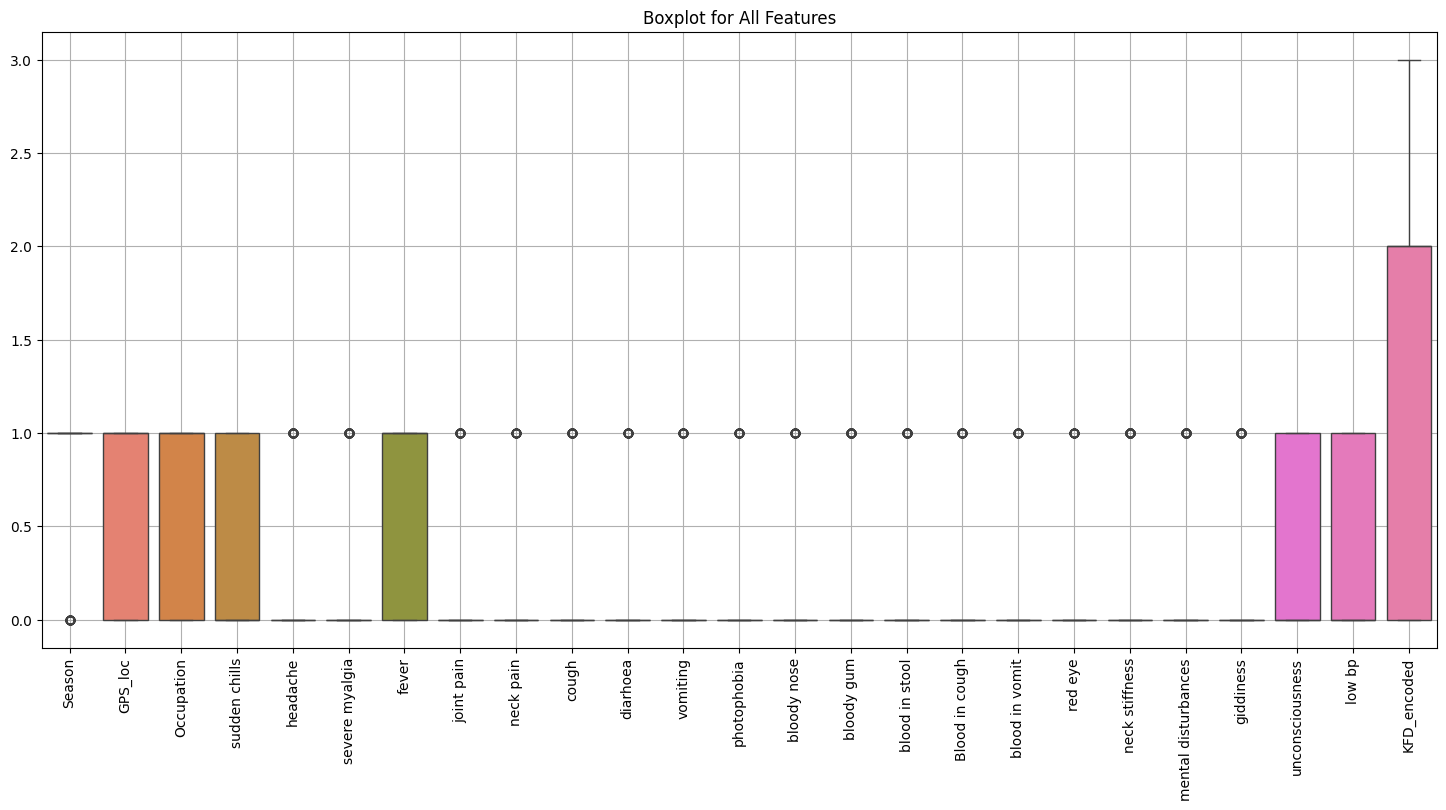

In [10]:
plt.figure(figsize=(18, 8))
sns.boxplot(data=df)
plt.title("Boxplot for All Features")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()


**Scaling the Data(MinMax Scaler)**

In [11]:
X = df[binary_columns].copy()
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

y = df['KFD_encoded']
y_categorical = to_categorical(y)

**Training and Testing Split**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical, test_size=0.2, random_state=42, stratify=y
)
X_train_seq = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_seq = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
n_classes = y_train.shape[1]


**Shape of Training and Testing values**

In [13]:
print("Custom label encoding:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))
print("Training shape:", X_train_seq.shape)
print("Test shape:", X_test_seq.shape)

Custom label encoding: {np.str_('Confirmed'): 0, np.str_('Negative'): 1, np.str_('Probable'): 2, np.str_('Suspected'): 3}
Training shape: (319, 24, 1)
Test shape: (80, 24, 1)


**Build CNN_LSTM Model**

In [14]:
def build_cnn_lstm(input_shape, n_classes):
    inp = Input(shape=input_shape)
    x = Conv1D(64, 3, activation='relu')(inp)
    x = MaxPooling1D(2)(x)
    x = LSTM(64)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(n_classes, activation='softmax')(x)
    return Model(inputs=inp, outputs=out, name='CNN_LSTM_Model')

cnn_lstm_model = build_cnn_lstm(X_train_seq.shape[1:], n_classes)
cnn_lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_lstm_model.fit(X_train_seq, y_train, epochs=30, batch_size=32, validation_split=0.1)
cnn_lstm_model.save("/content/cnn_lstm_model.keras")

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.2957 - loss: 1.3640 - val_accuracy: 0.2188 - val_loss: 1.3598
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3963 - loss: 1.2973 - val_accuracy: 0.2500 - val_loss: 1.3636
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5005 - loss: 1.1978 - val_accuracy: 0.3750 - val_loss: 1.3101
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5714 - loss: 1.1166 - val_accuracy: 0.4375 - val_loss: 1.2147
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5366 - loss: 1.0792 - val_accuracy: 0.4688 - val_loss: 1.1078
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5826 - loss: 0.9679 - val_accuracy: 0.5000 - val_loss: 1.0273
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6341 - loss: 0.9200 - val_accuracy: 0.5938 - val_loss: 0.9603
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6327 - loss: 0.9196 - val_accuracy: 0.6875 - val_loss: 0.9111


**Build GRU Model**

In [15]:
def build_gru(input_shape, n_classes):
    inp = Input(shape=input_shape)
    x = GRU(64, return_sequences=True)(inp)
    x = GRU(32)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(n_classes, activation='softmax')(x)
    return Model(inputs=inp, outputs=out, name='GRU_Model')

gru_model = build_gru(X_train_seq.shape[1:], n_classes)
gru_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
gru_model.fit(X_train_seq, y_train, epochs=30, batch_size=32, validation_split=0.1)
gru_model.save("/content/gru_model.keras")

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.3926 - loss: 1.3756 - val_accuracy: 0.3125 - val_loss: 1.3611
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4267 - loss: 1.3159 - val_accuracy: 0.3750 - val_loss: 1.3498
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4412 - loss: 1.2630 - val_accuracy: 0.3750 - val_loss: 1.3410
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5231 - loss: 1.1806 - val_accuracy: 0.4062 - val_loss: 1.2912
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5260 - loss: 1.1036 - val_accuracy: 0.3438 - val_loss: 1.2288
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5484 - loss: 1.0216 - val_accuracy: 0.4688 - val_loss: 1.0617
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6235 - loss: 0.9547 - val_accuracy: 0.6875 - val_loss: 0.8921
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6592 - loss: 0.8048 - val_accuracy: 0.6875 - val_loss: 0.8438

**Build Transformer Networks Model**

In [16]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = Add()([x, inputs])
    x = LayerNormalization(epsilon=1e-6)(x)
    x_ff = Dense(ff_dim, activation='relu')(x)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    return Add()([x, x_ff])

def build_transformer(input_shape, n_classes):
    inp = Input(shape=input_shape)
    x = transformer_encoder(inp, head_size=64, num_heads=4, ff_dim=128)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(n_classes, activation='softmax')(x)
    return Model(inputs=inp, outputs=out, name='Transformer_Model')

transformer_model = build_transformer(X_train_seq.shape[1:], n_classes)
transformer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
transformer_model.fit(X_train_seq, y_train, epochs=30, batch_size=32, validation_split=0.1)
transformer_model.save("/content/transformer_model.keras")


Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.3530 - loss: 1.3858 - val_accuracy: 0.3125 - val_loss: 1.3861
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4037 - loss: 1.3836 - val_accuracy: 0.3125 - val_loss: 1.3858
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4003 - loss: 1.3816 - val_accuracy: 0.3125 - val_loss: 1.3856
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3910 - loss: 1.3789 - val_accuracy: 0.3125 - val_loss: 1.3855
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4341 - loss: 1.3766 - val_accuracy: 0.3125 - val_loss: 1.3852
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3564 - loss: 1.3762 - val_accuracy: 0.3125 - val_loss: 1.3852
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4258 - loss: 1.3720 - val_accuracy: 0.3125 - val_loss: 1.3850
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3712 - loss: 1.3733 - val_accuracy: 0.3125 - val_loss: 1.3849


**Testing Models Via Classification Approach**

In [17]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

def evaluate(model, name, X_test_seq, y_test, label_encoder):
    preds = model.predict(X_test_seq)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = np.argmax(y_test, axis=1)
    acc = accuracy_score(true_labels, pred_labels)
    print(f"\n {name} Accuracy: {acc:.4f}")
    print(classification_report(true_labels, pred_labels, target_names=[str(cls) for cls in label_encoder.classes_]))


evaluate(cnn_lstm_model, "CNN-LSTM", X_test_seq, y_test, label_encoder)
evaluate(gru_model, "GRU", X_test_seq, y_test, label_encoder)
evaluate(transformer_model, "Transformer", X_test_seq, y_test, label_encoder)



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step

 CNN-LSTM Accuracy: 0.7500
              precision    recall  f1-score   support

   Confirmed       0.90      0.90      0.90        21
    Negative       1.00      0.87      0.93        15
    Probable       0.61      0.93      0.74        30
   Suspected       0.00      0.00      0.00        14

    accuracy                           0.75        80
   macro avg       0.63      0.68      0.64        80
weighted avg       0.65      0.75      0.69        80



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step

 GRU Accuracy: 0.7750
              precision    recall  f1-score   support

   Confirmed       0.84      1.00      0.91        21
    Negative       0.82      0.93      0.88        15
    Probable       0.71      0.90      0.79        30
   Suspected       0.00      0.00      0.00        14

    accuracy                           0.78        80
   macro avg       0.59      0.71      0.65        80
weighted avg       0.64      0.78      0.70        80



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

 Transformer Accuracy: 0.3750
              precision    recall  f1-score   support

   Confirmed       0.00      0.00      0.00        21
    Negative       0.00      0.00      0.00        15
    Probable       0.38      1.00      0.55        30
   Suspected       0.00      0.00      0.00        14

    accuracy                           0.38        80
   macro avg       0.09      0.25      0.14        80
weighted avg       0.14      0.38      0.20        80



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Making two Folders Templates,Static**

In [18]:
import os

# Create folders
os.makedirs("templates", exist_ok=True)
os.makedirs("static", exist_ok=True)



**Index Page**

In [19]:
index_html = """
<!DOCTYPE html>
<html>
<head>
    <title>Kyasanur Forest Disease Prediction</title>
    <link rel="stylesheet" href="/static/style.css">
</head>
<body>
    <div class="container">
        <div style="text-align: right; margin-bottom: 15px;">
            <a href="/logout" style="
                background-color: #e74c3c;
                color: white;
                padding: 8px 16px;
                text-decoration: none;
                font-weight: bold;
                border-radius: 6px;
            "> Logout</a>
        </div>

        <h1>Kyasanur Forest Disease Prediction</h1>

        <div class="team-info">
            <h3>Developed by:</h3>
            <p>RA2211003011436 - Yetukuri Gargeya Sreenadh</p>
            <p>RA2211003011414 - Marni Jaswanth</p>
        </div>

        <form method="POST" action="/predict">
            <div class="form-group">
                <label for="model">Choose Model:</label>
                <select name="model" id="model">
                    <option value="cnn_lstm">CNN-LSTM</option>
                    <option value="gru">GRU</option>
                    <option value="transformer">Transformer</option>
                </select>
            </div>

            <div class="form-section">
                <h3>Environmental Factors</h3>
                <div class="form-group">
                    <label for="Season">Is it KFD Season (Dec-May)?</label>
                    <select name="Season" required>
                        <option value="">-- Select --</option>
                        <option value="Y">Yes</option>
                        <option value="N">No</option>
                    </select>
                </div>

                <div class="form-group">
                    <label for="GPS_loc">GPS Location Tagged in Endemic Area?</label>
                    <select name="GPS_loc" required>
                        <option value="">-- Select --</option>
                        <option value="Y">Yes</option>
                        <option value="N">No</option>
                    </select>
                </div>

                <div class="form-group">
                    <label for="Occupation">Occupation Forest-related?</label>
                    <select name="Occupation" required>
                        <option value="">-- Select --</option>
                        <option value="Y">Yes</option>
                        <option value="N">No</option>
                    </select>
                </div>
            </div>

            <div class="form-section">
                <h3>Symptoms</h3>
                {% for symptom in symptoms %}
                    <div class="form-group">
                        <label for="{{ symptom }}">{{ symptom|title }}?</label>
                        <select name="{{ symptom }}" required>
                            <option value="">-- Select --</option>
                            <option value="Y">Yes</option>
                            <option value="N">No</option>
                        </select>
                    </div>
                {% endfor %}
            </div>

            <button type="submit">Predict Disease Status</button>
        </form>
    </div>
</body>
</html>

"""

with open("templates/index.html", "w") as f:
    f.write(index_html)


**Login Page**

In [20]:
login_html="""

<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <title>KFD Login / Signup</title>
  <link rel="stylesheet" href="/static/style.css">
  <style>
    body {
      background: linear-gradient(to right, #283e51, #485563);
      font-family: 'Segoe UI', sans-serif;
      display: flex;
      align-items: center;
      justify-content: center;
      min-height: 100vh;
      margin: 0;
    }
    .auth-box {
      background: white;
      border-radius: 20px;
      box-shadow: 0 10px 30px rgba(0, 0, 0, 0.2);
      max-width: 420px;
      width: 90%;
      padding: 40px 30px;
      text-align: center;
    }
    .alert-box {
      padding: 10px;
      margin-bottom: 15px;
      border-radius: 5px;
      font-weight: bold;
    }
    .success { background-color: #d4edda; color: #155724; }
    .error { background-color: #f8d7da; color: #721c24; }
    .hidden { display: none; }
    input { margin-bottom: 12px; }
    .switch-text span {
      cursor: pointer;
      text-decoration: underline;
      color: #3498db;
    }
    .project-header {
      margin-bottom: 20px;
    }
    .project-header h2 {
      margin: 0;
      font-size: 20px;
      color: #2c3e50;
    }
    .project-header p {
      margin: 4px 0;
      font-size: 13px;
      color: #444;
    }
  </style>
</head>
<body>
<div class="auth-box">
  <div class="project-header">
    <h2>Kyasanur Forest Disease Prediction</h2>
    <p><strong>Developed by:</strong></p>
    <p>RA2211003011436 - Yetukuri Gargeya Sreenadh</p>
    <p>RA2211003011414 - Marni Jaswanth</p>
  </div>

  <h2 id="form-title">Login to Your Account</h2>
  {% with messages = get_flashed_messages(with_categories=true) %}
    {% if messages %}
      {% for category, message in messages %}
        <div class="alert-box {{ category }}">{{ message }}</div>
      {% endfor %}
    {% endif %}
  {% endwith %}

  <div id="login-container">
    <form method="POST">
      <input type="text" name="username" placeholder="Username" required>
      <input type="password" name="password" placeholder="Password" required>
      <button type="submit" name="login">Login</button>
    </form>
    <p class="switch-text">New user? <span id="show-signup">Create an account</span></p>
  </div>

  <div id="signup-container" class="hidden">
    <form method="POST">
      <input type="text" name="username" placeholder="New Username" required>
      <input type="password" name="password" placeholder="New Password" required>
      <button type="submit" name="signup">Create Account</button>
    </form>
    <p class="switch-text">Already have an account? <span id="show-login">Login here</span></p>
  </div>
</div>

<script>
  const loginContainer = document.getElementById('login-container');
  const signupContainer = document.getElementById('signup-container');
  const formTitle = document.getElementById('form-title');
  document.getElementById('show-signup').onclick = () => {
    loginContainer.classList.add('hidden');
    signupContainer.classList.remove('hidden');
    formTitle.textContent = 'Create a New Account';
  };
  document.getElementById('show-login').onclick = () => {
    signupContainer.classList.add('hidden');
    loginContainer.classList.remove('hidden');
    formTitle.textContent = 'Login to Your Account';
  };
</script>
</body>
</html>


"""
with open("templates/login.html", "w") as f:
    f.write(login_html)

**Admin Page**

In [21]:
admin_html="""
<!DOCTYPE html>
<html>
<head>
    <title>Admin Dashboard</title>
    <link rel="stylesheet" href="/static/style.css">
    <style>
        body {
            background: #f4f6f9;
            font-family: 'Segoe UI', sans-serif;
            margin: 0;
            padding: 0;
        }
        .container {
            max-width: 1100px;
            margin: 40px auto;
            padding: 30px;
            background: white;
            border-radius: 12px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.05);
        }
        .project-header {
            text-align: center;
            margin-bottom: 30px;
        }
        .project-header h1 {
            margin-bottom: 5px;
            color: #2c3e50;
        }
        .project-header p {
            margin: 0;
            font-size: 14px;
        }
        .dashboard-section {
            background: #fdfefe;
            padding: 25px;
            border-radius: 12px;
            margin-bottom: 30px;
            box-shadow: 0 4px 12px rgba(0,0,0,0.05);
        }
        .dashboard-section h3 {
            margin-top: 0;
            color: #2c3e50;
        }
        table {
            width: 100%;
            border-collapse: collapse;
            margin-top: 15px;
        }
        th, td {
            padding: 10px;
            border: 1px solid #ddd;
            text-align: center;
        }
        th {
            background: #3498db;
            color: white;
        }
        .chart-grid {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 20px;
        }
        .chart-box img {
            width: 100%;
            border-radius: 10px;
            box-shadow: 0 3px 8px rgba(0,0,0,0.1);
        }
        .nav-links {
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 20px;
        }
        .nav-links a {
            padding: 10px 20px;
            background-color: #3498db;
            color: white;
            border-radius: 8px;
            text-decoration: none;
            font-weight: bold;
            transition: background-color 0.3s;
        }
        .nav-links a:hover {
            background-color: #2c80b4;
        }
    </style>
</head>
<body>
<div class="container">
    <div class="nav-links">
        <a href="/logout"> Logout</a>
        <a href="/"> Go to Prediction Dashboard</a>
    </div>

    <div class="project-header">
        <h1>Kyasanur Forest Disease Prediction</h1>
        <p><strong>Developed by:</strong></p>
        <p>RA2211003011436 - Yetukuri Gargeya Sreenadh</p>
        <p>RA2211003011414 - Marni Jaswanth</p>
    </div>

    <div class="dashboard-section">
        <h3>Prediction Logs</h3>
        {% if logs %}
        <table>
            <tr><th>User ID</th><th>Model</th><th>Prediction</th></tr>
            {% for log in logs %}
                <tr>
                    <td>{{ log.user_id }}</td>
                    <td>{{ log.model_used }}</td>
                    <td>{{ log.prediction }}</td>
                </tr>
            {% endfor %}
        </table>
        {% else %}
            <p>No predictions made yet.</p>
        {% endif %}
    </div>

    <div class="dashboard-section">
        <h3>Prediction Visualizations</h3>
        <div class="chart-grid">
            {% if chart_bar %}
            <div class="chart-box">
                <h4>Prediction Distribution</h4>
                <img src="{{ chart_bar }}" alt="Bar Chart">
            </div>
            {% endif %}
            {% if chart_pie %}
            <div class="chart-box">
                <h4>Prediction Share</h4>
                <img src="{{ chart_pie }}" alt="Pie Chart">
            </div>
            {% endif %}
        </div>
    </div>
</div>
</body>
</html>


"""
with open("templates/admin.html", "w") as f:
    f.write(admin_html)

**Results Page**

In [22]:
result_html = """
<!DOCTYPE html>
<html>
<head>
    <title>KFD Prediction Result</title>
    <link rel="stylesheet" href="/static/style.css">
</head>
<body>
    <div class="container result-container">
        <div style="text-align: right; margin-bottom: 15px;">
            <a href="/logout" style="
                background-color: #e74c3c;
                color: white;
                padding: 8px 16px;
                text-decoration: none;
                font-weight: bold;
                border-radius: 6px;
            "> Logout</a>
        </div>

        <h1>Kyasanur Forest Disease Prediction</h1>

        <div class="team-info">
            <h3>Developed by:</h3>
            <p>RA2211003011436 - Yetukuri Gargeya Sreenadh</p>
            <p>RA2211003011414 - Marni Jaswanth</p>
        </div>

        <div class="result-box">
            <h2>Prediction Result</h2>
            <div class="prediction-result">
                {{ prediction_text | safe }}
            </div>
            <div class="model-info">
                <p>Model used: <strong>{{ model_used }}</strong></p>
            </div>
        </div>

        <div class="info-box">
            <h3>About KFD</h3>
            <p>Kyasanur Forest Disease is a tick-borne viral hemorrhagic fever endemic to South Asia. Early detection is crucial for proper treatment and prevention of complications.</p>
        </div>

        <a href="/" class="back-button"> Back to Prediction Form</a>
    </div>
</body>
</html>

"""

with open("templates/result.html", "w") as f:
    f.write(result_html)


**Styling**

In [23]:
style_css = """
body {
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%);
    margin: 0;
    padding: 20px;
    min-height: 100vh;
}

.container {
    background-color: white;
    max-width: 800px;
    width: 90%;
    margin: 30px auto;
    padding: 30px;
    border-radius: 15px;
    box-shadow: 0 5px 25px rgba(0,0,0,0.1);
}

h1 {
    text-align: center;
    margin-bottom: 15px;
    color: #2c3e50;
    font-size: 28px;
    border-bottom: 2px solid #3498db;
    padding-bottom: 10px;
}

h2 {
    color: #2c3e50;
    margin-top: 25px;
}

h3 {
    color: #3498db;
    margin-top: 20px;
    margin-bottom: 10px;
    font-size: 18px;
}

.team-info {
    background-color: #f8f9fa;
    padding: 15px;
    border-radius: 10px;
    margin-bottom: 25px;
    text-align: center;
}

.team-info h3 {
    margin-top: 0;
    color: #2c3e50;
}

.team-info p {
    margin: 5px 0;
    font-weight: 500;
}

.form-section {
    background-color: #f8f9fa;
    padding: 20px;
    border-radius: 10px;
    margin-bottom: 20px;
}

.form-group {
    margin-bottom: 15px;
}

label {
    display: block;
    margin-bottom: 8px;
    font-weight: 500;
    color: #34495e;
}

input, select {
    width: 100%;
    padding: 12px;
    border: 1px solid #ddd;
    border-radius: 8px;
    box-sizing: border-box;
    font-size: 16px;
    transition: border-color 0.3s;
}

select:focus, input:focus {
    border-color: #3498db;
    outline: none;
    box-shadow: 0 0 0 2px rgba(52, 152, 219, 0.25);
}

button {
    width: 100%;
    padding: 15px;
    background-color: #3498db;
    border: none;
    color: white;
    font-size: 18px;
    font-weight: bold;
    border-radius: 8px;
    cursor: pointer;
    transition: all 0.3s ease;
    margin-top: 20px;
}

button:hover {
    background-color: #2980b9;
    transform: translateY(-2px);
    box-shadow: 0 5px 15px rgba(0,0,0,0.1);
}

.result-container {
    text-align: center;
}

.result-box {
    background-color: #f8f9fa;
    padding: 25px;
    border-radius: 10px;
    margin: 25px 0;
    border-left: 5px solid #3498db;
}

.prediction-result {
    font-size: 24px;
    font-weight: bold;
    margin: 20px 0;
    padding: 15px;
    border-radius: 8px;
    color: #2c3e50;
}

.model-info {
    display: flex;
    justify-content: space-around;
    margin-top: 20px;
    padding-top: 15px;
    border-top: 1px solid #ddd;
}

.info-box {
    background-color: #ebf5fb;
    padding: 20px;
    border-radius: 10px;
    margin: 25px 0;
    text-align: left;
}

.back-button {
    display: inline-block;
    padding: 12px 25px;
    background-color: #34495e;
    color: white;
    text-decoration: none;
    border-radius: 8px;
    transition: all 0.3s ease;
    margin-top: 20px;
    font-weight: bold;
}

.back-button:hover {
    background-color: #2c3e50;
    transform: translateY(-2px);
    box-shadow: 0 5px 15px rgba(0,0,0,0.1);
}

/* Status colors */
.status-confirmed {
    color: #e74c3c;
}

.status-negative {
    color: #2ecc71;
}

.status-probable, .status-suspected {
    color: #f39c12;
}
"""

with open("static/style.css", "w") as f:
    f.write(style_css)


**APP for User Interface**

In [24]:
app_py = """



from flask import Flask, render_template, request, redirect
from flask_sqlalchemy import SQLAlchemy
from flask_login import LoginManager, UserMixin, login_user, login_required, logout_user, current_user
import numpy as np
import tensorflow as tf
import os, signal, time, io, base64, psutil, threading
from pyngrok import ngrok
import matplotlib.pyplot as plt

app = Flask(__name__)
app.config['SECRET_KEY'] = 'kfd-secret-key'
app.config['SQLALCHEMY_DATABASE_URI'] = 'sqlite:///kfd_users.db'
app.config['SQLALCHEMY_TRACK_MODIFICATIONS'] = False

db = SQLAlchemy(app)
login_manager = LoginManager()
login_manager.init_app(app)
login_manager.login_view = 'login'


class User(UserMixin, db.Model):
    id = db.Column(db.Integer, primary_key=True)
    username = db.Column(db.String(100), unique=True)
    password = db.Column(db.String(100))
    is_admin = db.Column(db.Boolean, default=False)

class PredictionLog(db.Model):
    id = db.Column(db.Integer, primary_key=True)
    user_id = db.Column(db.Integer)
    model_used = db.Column(db.String(50))
    prediction = db.Column(db.String(100))

with app.app_context():
    db.create_all()


try:
    model_cnn_lstm = tf.keras.models.load_model('/content/cnn_lstm_model.keras')
    model_gru = tf.keras.models.load_model('/content/gru_model.keras')
    model_transformer = tf.keras.models.load_model('/content/transformer_model.keras')
    models_loaded = True
except Exception as e:
    print("Model load error:", e)
    models_loaded = False


@login_manager.user_loader
def load_user(user_id):
    return User.query.get(int(user_id))


symptoms = [
    'sudden chills', 'headache', 'severe myalgia', 'fever',
    'joint pain', 'neck pain', 'cough', 'diarhoea', 'vomiting',
    'photophobia', 'bloody nose', 'bloody gum', 'blood in stool',
    'Blood in cough', 'blood in vomit', 'red eye', 'neck stiffness',
    'mental disturbances', 'giddiness', 'unconsciousness', 'low bp'
]

class_names = {
    0: {"label": "Confirmed", "description": "High probability of KFD infection based on symptoms.", "class_style": "status-confirmed"},
    1: {"label": "Negative", "description": "KFD infection unlikely based on current symptoms.", "class_style": "status-negative"},
    2: {"label": "Probable", "description": "Significant risk factors for KFD present.", "class_style": "status-probable"},
    3: {"label": "Suspected", "description": "Some indicators of KFD — testing recommended.", "class_style": "status-suspected"}
}


def preprocess_input(form_data):
    binary_map = {'Y': 1, 'N': 0}
    features = [
        binary_map.get(form_data.get('Season', 'N'), 0),
        binary_map.get(form_data.get('GPS_loc', 'N'), 0),
        binary_map.get(form_data.get('Occupation', 'N'), 0)
    ]
    for symptom in symptoms:
        features.append(binary_map.get(form_data.get(symptom, 'N'), 0))
    return np.array(features).reshape(1, 24, 1)

def render_chart(fig):
    img = io.BytesIO()
    fig.savefig(img, format='png', bbox_inches='tight')
    plt.close(fig)
    img.seek(0)
    return 'data:image/png;base64,{}'.format(base64.b64encode(img.getvalue()).decode())

def kill_existing_ngrok_processes():
    for proc in psutil.process_iter(['pid', 'name']):
        try:
            if 'ngrok' in proc.info['name'].lower():
                os.kill(proc.info['pid'], signal.SIGTERM)
        except:
            pass

def setup_ngrok(port):
    kill_existing_ngrok_processes()
    time.sleep(2)
    return ngrok.connect(addr=port, proto='http')


@app.route('/')
@login_required
def home():
    return render_template('index.html', symptoms=symptoms, models_loaded=models_loaded)

@app.route('/predict', methods=['POST'])
@login_required
def predict():
    if not models_loaded:
        return render_template('result.html', prediction_text='<div class="status-error">Models not loaded</div>', model_used="None")

    model_choice = request.form['model']
    input_data = preprocess_input(request.form)

    model_names = {
        'cnn_lstm': 'CNN-LSTM Neural Network',
        'gru': 'Gated Recurrent Unit (GRU)',
        'transformer': 'Transformer Neural Network'
    }

    model_map = {
        'cnn_lstm': model_cnn_lstm,
        'gru': model_gru,
        'transformer': model_transformer
    }

    prediction = model_map[model_choice].predict(input_data)[0]
    model_used = model_names[model_choice]
    predicted_class = int(np.argmax(prediction))
    status_info = class_names.get(predicted_class, {"label": "Unknown", "description": "Could not determine status.", "class_style": ""})

    result = f'<div class="{status_info["class_style"]}">KFD Status: {status_info["label"]}</div>'
    result += f'<p>{status_info["description"]}</p>'

    if current_user.is_authenticated:
        log = PredictionLog(user_id=current_user.id, model_used=model_choice, prediction=status_info["label"])
        db.session.add(log)
        db.session.commit()

    return render_template('result.html', prediction_text=result, model_used=model_used)

@app.route('/login', methods=['GET', 'POST'])
def login():
    if request.method == 'POST':
        if 'signup' in request.form:
            username = request.form['username']
            password = request.form['password']
            if not User.query.filter_by(username=username).first():
                user = User(username=username, password=password)
                db.session.add(user)
                db.session.commit()
                return 'User created! Please login.'
            return 'Username already exists!'
        else:
            user = User.query.filter_by(username=request.form['username']).first()
            if user and user.password == request.form['password']:
                login_user(user)
                return redirect('/admin' if user.is_admin else '/')
            return 'Invalid credentials'
    return render_template('login.html')

@app.route('/logout')
@login_required
def logout():
    logout_user()
    return redirect('/login')

@app.route('/admin')
@login_required
def admin():
    if not current_user.is_admin:
        return 'Unauthorized', 403

    logs = PredictionLog.query.all()
    prediction_counts = {}
    all_preds = []

    for log in logs:
        prediction_counts[log.prediction] = prediction_counts.get(log.prediction, 0) + 1
        all_preds.append(log.prediction)

    # Bar Chart
    fig1, ax1 = plt.subplots()
    ax1.bar(prediction_counts.keys(), prediction_counts.values(), color='skyblue')
    ax1.set_title('Prediction Distribution')
    chart_bar = render_chart(fig1)

    # Heatmap (dummy data)
    fig2, ax2 = plt.subplots()
    dummy_data = np.random.rand(4, 4)
    heatmap = ax2.imshow(dummy_data, cmap='Blues')
    fig2.colorbar(heatmap)
    ax2.set_title('Heatmap of Dummy Correlation')
    chart_heatmap = render_chart(fig2)

    # Histogram
    fig3, ax3 = plt.subplots()
    ax3.hist(all_preds, bins=len(set(all_preds)), color='salmon', edgecolor='black')
    ax3.set_title('Histogram of Predictions')
    chart_hist = render_chart(fig3)

    return render_template('admin.html', logs=logs, chart_bar=chart_bar, chart_heatmap=chart_heatmap, chart_hist=chart_hist)


if __name__ == '__main__':
    port = 5000
    threading.Thread(target=lambda: app.run(host='0.0.0.0', port=port, debug=True, use_reloader=False)).start()
    time.sleep(3)
    public_url = setup_ngrok(port)
    print("🌐 Public Ngrok URL:", public_url)

"""

with open("app.py", "w") as f:
    f.write(app_py)


**Configuration**

In [25]:
!pip install flask flask_sqlalchemy flask_login pyngrok matplotlib

!pip install flask pyngrok

!ngrok config add-authtoken 2o1PVSrtWV35p8mAYGNj5unkwL6_3zbEqpUv37ehhc5bV9F8H





Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


**Python App**

In [27]:
from app import app, db, User

with app.app_context():
    admin = User(username="admin", password="admin123", is_admin=True)
    db.session.add(admin)
    db.session.commit()

print("✅ Admin created.")


✅ Admin created.


In [28]:
!python app.py

2025-04-14 03:34:05.931138: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744601646.043343    3047 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744601646.077545    3047 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-14 03:34:12.825377: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
 * Serving Flask app 'app'
 * Debug mode: on
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
Press CTRL+C to quit
🌐 Public Ngrok URL: NgrokTunnel: "https://bd2a-34-121-206-88.ngrok-free.app" 